# 🎓 Aula Prática: Avaliação de Pipelines RAG sem Ground Truth
**Disciplina:** GENERATIVE AI & ADAVANCED NETS

**Curso:** Tecnólogo em Inteligência Artificial

---

## 📌 Objetivos de Aprendizagem
Ao final desta sessão prática, você será capaz de:
1. Compreender o paradigma **LLM-as-a-Judge** em cenários sem gabarito prévio (*Ground Truth*).
2. Aplicar as **métricas avançadas do Ragas sem referência** para isolar falhas no *Retriever* e no *Generator*.
3. Gerar e interpretar **Gráficos de Radar (Teia de Aranha)** para obter a assinatura de diagnóstico de um pipeline RAG.
4. Criar datasets sintéticos para avaliação de soluções com RAG.

# Desafios da Avaliação de Sistemas RAG
Em sistemas RAG reais, especialmente em produção e em larga escala, nem sempre existe um conjunto de respostas anotadas para servir como referência. Dessa forma, torna-se fundamental utilizar métricas que avaliem a qualidade do retrieval e da generation, combinando métricas baseadas em ground truth com métricas que podem ser aplicadas mesmo na ausência de dados anotados.

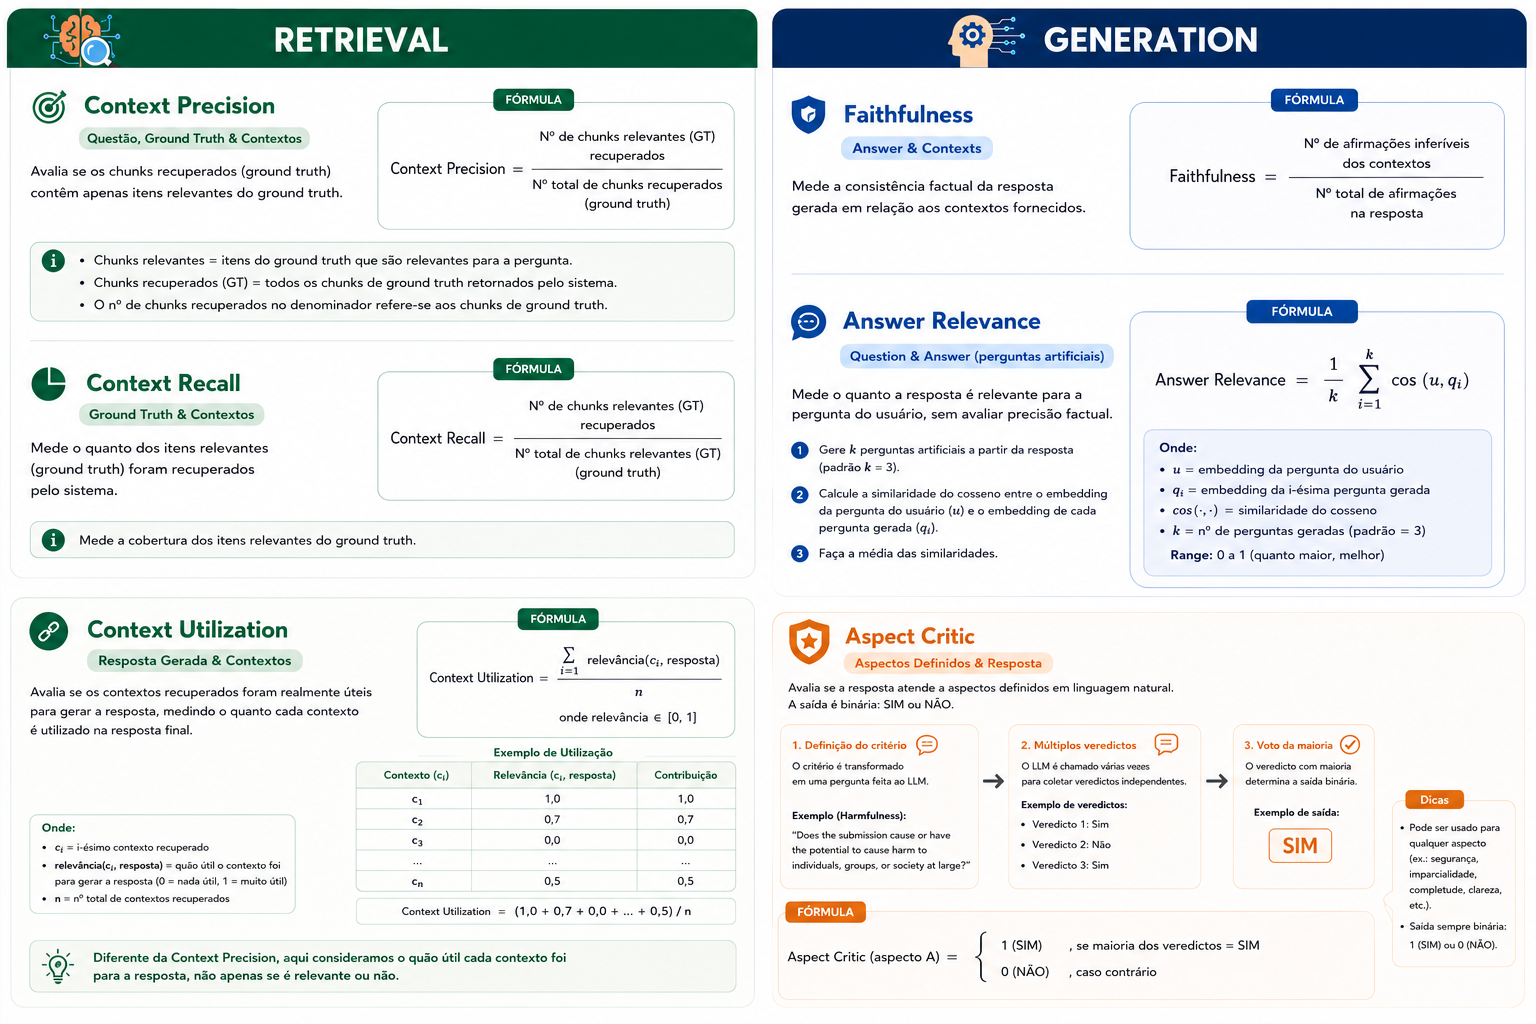

## 🛠️ Seção 1

### Configuração do Ambiente

In [ ]:
!pip install -U \
    ragas==0.4.3 \
    "langchain<1.0" \
    "langchain-community<0.4" \
    langchain-google-genai \
    rapidfuzz

### Importando Bibliotecas

In [ ]:
import os

import warnings
# Filtrar warnings
warnings.filterwarnings("ignore")

import pandas as pd
import plotly.express as px
from datasets import Dataset
from google.colab import userdata
from langchain_core.documents import Document
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
    GoogleGenerativeAIEmbeddings,
)
from ragas import evaluate
from ragas.metrics import (
    AnswerRelevancy,
    AspectCritic,
    ContextUtilization,
    Faithfulness,
    AnswerCorrectness
)
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
from ragas.testset import TestsetGenerator


### Configurando Chaves da API do GEMINI

In [ ]:
# Recupera a chave da API
try:
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    print("✅ Chave GOOGLE_API_KEY carregada dos Secrets do Colab!")
except Exception:
    import getpass
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Insira sua GOOGLE_API_KEY: ")


GOOGLE_API_KEY = os.environ["GOOGLE_API_KEY"]

### Autenticação do LLM Evaluator (Gemini)
Utilizaremos o **Google Gemini** como nosso *LLM-as-a-Judge*. Certifique-se de salvar sua chave `GOOGLE_API_KEY` nos *Secrets* do Colab (ícone de chave na barra lateral esquerda) ou inseri-la de forma segura abaixo.

In [ ]:
#TODO Carregue o evaluator_llm e o evaluator_embeddings


In [ ]:
#TODO Estabeleça o rate_limiter usando InMemoryRateLimiter


---
## 📊 Seção 2: Construção do Dataset de Avaliação (*TechCorp Policy Dataset*)

Em cenários corporativos reais, raramente temos o gabarito ideal (*Ground Truth*) escrito por especialistas para todas as perguntas do usuário. Avaliaremos o sistema RAG analisando a tríade: **Pergunta (User Input)**, **Contexto Recuperado (Retrieved Contexts)** e **Resposta Gerada (Response)**.

Construiremos um dataset sintético com **5 cenários controlados** representando diferentes comportamentos do RAG:

In [ ]:
data = {
    "user_input": [
        "Qual é a política de reembolso para cursos e certificações na TechCorp?",
        "Quantos dias de trabalho remoto são permitidos por semana?",
        "Como devo proceder em caso de incidente de segurança da informação?",
        "Quais são as etapas para a solicitação de um novo equipamento de trabalho?",
        "Quais são as regras para licença não remunerada e seu impacto nos benefícios?"
    ],
    "retrieved_contexts": [

        ["A TechCorp reembolsa até 80% do valor de cursos e certificações técnicas aprovadas pelo gestor, limitado a R$ 3.000 por ano por colaborador."],
        ["A política da TechCorp permite até 2 dias de trabalho remoto por semana, mediante alinhamento prévio com a liderança imediata."],
        [
            "O cardápio do restaurante corporativo é atualizado semanalmente no portal interno.",
            "As reuniões gerais da empresa ocorrem na primeira sexta-feira de cada mês.",
            "Em caso de incidente de segurança, notifique imediatamente a equipe de SecOps pelo canal #security-alert no Slack e abra um chamado prioritário."
        ],
        ["Para solicitar novo equipamento: 1. Abra um chamado no portal de TI. 2. Obtenha aprovação orçamentária do gestor. 3. Aguarde a validação do inventário de hardware."],
        ["A licença não remunerada pode ser solicitada por colaboradores com mais de 2 anos de casa, por um período máximo de 6 meses."]
    ],
    "response": [
        # Caso 1: Perfeito
        "A TechCorp reembolsa até 80% do valor de cursos e certificações técnicas aprovadas pelo seu gestor, com limite de R$ 3.000 por ano.",
        # Caso 2: Alucinação (Afirma que o reembolso é 100% e exige 1 ano de casa)
        "Você pode fazer até 5 dias de trabalho remoto e a empresa cobre 100% dos custos de infraestrutura residencial após 1 ano de empresa.",
        # Caso 3: Afetado por ruído
        "Você deve notificar a equipe de SecOps pelo canal #security-alert no Slack e abrir um chamado prioritário. Lembre-se também de verificar o cardápio do restaurante no portal.",
        # Caso 4: Subutilizado (Menciona apenas 1 etapa)
        "Para solicitar um novo equipamento, basta abrir um chamado no portal de TI.",
        # Caso 5: Incompleto por falta de dados no contexto
        "Nossa documentação informa apenas que a licença pode ser solicitada por colaboradores com mais de dois anos de empresa por até seis meses."
    ]
}

# Criação do DataFrame e Dataset do Hugging Face
df_eval = pd.DataFrame(data)
eval_dataset = Dataset.from_pandas(df_eval)

# Exibição do dataset
print(f"✅ Dataset construído com {len(df_eval)} casos de teste corporativos:")
display(df_eval[["user_input", "retrieved_contexts", "response"]])

---
## 🧪 Seção 3: Avaliação Completa com RAGAS (Métricas sem Ground Truth)

Configuraremos as **6 métricas avançadas** do Ragas que dispensam o uso de gabarito humano:

### 🧠 Métricas do Gerador (Generator)
1. **Faithfulness (Fidelidade):** Avalia se a resposta contém apenas afirmações derivadas diretamente do contexto recuperado (Mede alucinação).
2. **Answer Relevance (Relevância da Resposta):** Avalia se a resposta atende diretamente ao que foi perguntado.
3. **Context Utilization (Utilização do Contexto):** Mede quanto do conteúdo relevante trazido foi efetivamente incorporado na resposta final.
4. **Noise Sensitivity (Sensibilidade ao Ruído):** Avalia o quanto a resposta foi contaminada por informações irrelevantes presentes no contexto.

### 🔍 Métricas do Recuperador (Retriever)
5. **LLM-based Context Recall:** Avalia se o contexto recuperado contém a informação necessária para responder adequadamente à dúvida.
6. **Context Precision (sem referência):** Avalia a capacidade do retriever em posicionar os trechos mais relevantes no topo da lista recuperada.

In [ ]:
#TODO Crie uma métrica de conciseness_and_focus e uma noise_avoidance usando
# AspectCritic (Julga um aspecto específico com base em uma regra customizada)

In [ ]:
#TODO Crie uma lista com as métricas desejadas: Faithfulness, AnswerRelevancy,
# ContextUtilization, conciseness_critic e noise_critic


In [ ]:
#TODO Crie o pipeline de avaliação do Ragas usando evaluate com max_workers=1,
# max_retries=10 e max_wait=60


In [ ]:
#TODO Converta o resultado para pandas usando to_pandas()


### RAGAS é suficiente? Conhecendo outras alternativas

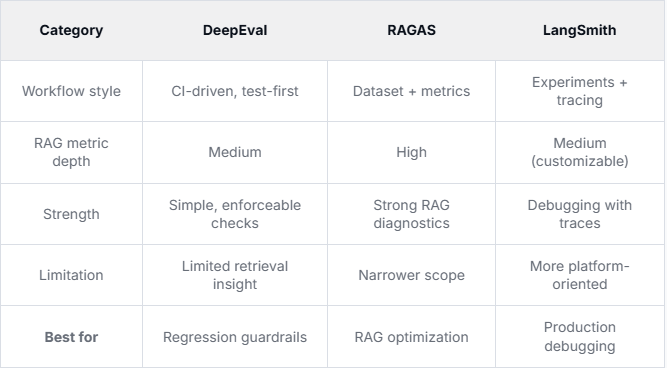

---
## 📈 Seção 4: Visualização e Diagnóstico de Resultados (Gráfico de Radar)

O **Gráfico de Radar (Teia de Aranha)** sintetiza a saúde do RAG. Uma teia deformada indica onde está o gargalo:
- **Deformação do lado das métricas do Retriever:** Problemas no Chunking, embeddings ou busca vetorial.
- **Deformação do lado das métricas do Generator:** Problemas de Prompt Engineering, escolha da LLM ou contexto poluído.

In [ ]:
# Seleção e renomeação das colunas de métricas para visualização
metric_cols = [
    'faithfulness',
    'answer_relevancy',
    'context_utilization',
    'conciseness_and_focus',
    'noise_avoidance',
    'question_answered'
]

# Garantir apenas métricas existentes no DataFrame de resultados
available_metrics = [col for col in metric_cols if col in results_df.columns]

# Cálculo das médias gerais do sistema
mean_scores = results_df[available_metrics].mean().to_dict()

radar_data = pd.DataFrame({
    'Métrica': list(mean_scores.keys()),
    'Score': list(mean_scores.values())
})

# Plot do Gráfico de Radar Interativo com Plotly
fig = px.line_polar(
    radar_data,
    r='Score',
    theta='Métrica',
    line_close=True,
    title='🕸️ Assinatura de Saúde do Pipeline RAG (Gráfico de Radar)',
    range_r=[0, 1]
)
fig.update_traces(fill='toself')
fig.show()

# Exibição da Tabela de Diagnóstico Detalhada por Caso de Teste
print("📌 Detalhamento do Score por Caso de Teste:")
display(results_df[['user_input', 'retrieved_contexts', 'response'] + available_metrics].style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

| Índice | Resumo                                                                                                                       |
| ------ | ---------------------------------------------------------------------------------------------------------------------------- |
| **0**  | Resposta totalmente consistente com o contexto: fiel, relevante, completa e sem ruído.                                       |
| **1**  | Resposta contradiz o contexto e adiciona informações inexistentes, resultando em forte penalização.                          |
| **2**  | A resposta acerta a informação principal, mas inclui conteúdo irrelevante, reduzindo fidelidade, concisão e uso do contexto. |
| **3**  | Resposta incompleta, utilizando apenas parte das informações disponíveis.                                        |
| **4**  | Resposta fiel ao contexto, mas não responde completamente à pergunta, reduzindo a relevância.                                |


---
## 🔬 Seção 5: Demonstração Prática: Geração de Dataset Sintético (TestsetGenerator)

E se não tivermos logs de RAG para avaliar? O Ragas possui o módulo TestsetGenerator, que lê documentos brutos da empresa e utiliza LLMs para gerar automaticamente pares sintéticos de perguntas, contextos e respostas.

In [ ]:
# Raw corporate text document
raw_policy_text = """
Política de Segurança da Informação TechCorp (2026):
Todos os colaboradores são obrigados a utilizar autenticação em dois fatores (2FA) em suas contas corporativas.
A criação de senhas deve conter no mínimo 12 caracteres, incluindo símbolos e números.
É estritamente proibido o uso de dispositivos USB pessoais em notebooks da empresa.
Qualquer suspeita de vazamento de dados deve ser comunicada em até 2 horas para a equipe de SOC via e-mail soc@techcorp.com.
"""

# Wrap raw text into the LangChain Document format
documents = [Document(page_content=raw_policy_text, metadata={"source": "security_policy.txt"})]

In [ ]:
#TODO Instanciar o TestsetGenerator com o llm sendo o evaluator_llm e o
# embedding_model sendo o  evaluator_embeddings


In [ ]:
#TODO Gere um pequeno dataset sintético com generator.generate_with_langchain_docs
#consfigurando o testset_size

In [ ]:
#TODO Convertar o synthetic_testset para pandas usando to_pandas()

# 🎯 Conclusão

Nesta aula prática, vimos como:
- **Usar LLM-as-a-Judge** para auditar pipelines RAG sem depender de gabaritos manuais ou anotações custosas.
- **Interpretar gargalos** da solução visualmente através de Gráficos de Radar.
- **Gerar dados sintéticos de teste** para avaliação automatizada utilizando o `TestsetGenerator`.

---

## 🚀 Considerações Práticas

- **DeepEval como Alternativa:** Ferramentas como o DeepEval possuem proposta semelhante ao RAGAS, mas com foco nativo na integração com frameworks de testes unitários em Python (como o `pytest`).
- **Automação em CI/CD:** A avaliação sem *ground truth* permite criar etapas em esteiras de CI/CD (ex: GitHub Actions) para barrar *deploys* de novos prompts ou documentos que reduzam a fidelidade do sistema.
- **Guardrails e Fine-Tuning:** Os diagnósticos da avaliação podem alimentar filtros de segurança (*Guardrails*) em tempo de execução ou servir de dataset para o *Fine-Tuning* do LLM gerador.